In [1]:
# For loading from cmbml directory (temporary solution)
import sys
import os

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, repo_root)

In [23]:
from pathlib import Path

import numpy as np
import healpy as hp

import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator

from cmbml.utils.planck_cmap import colombi1_cmap

In [13]:
map_unit = "$\\mu K_{CMB}^2$"

def get_lmax_for_map(some_map):
    nside = hp.get_nside(some_map)
    return 3 * nside - 1

dets = [30, 44, 70, 100, 143, 217, 353, 545, 857]

In [4]:
asset_root = Path("/data/jim/CMB_Data/Assets/Planck")
fns = {
    30: "LFI_SkyMap_030-BPassCorrected_1024_R3.00_full.fits",
    44: "LFI_SkyMap_044-BPassCorrected_1024_R3.00_full.fits",
    70: "LFI_SkyMap_070-BPassCorrected_1024_R3.00_full.fits",
    100: "HFI_SkyMap_100_2048_R3.01_full.fits",
    143: "HFI_SkyMap_143_2048_R3.01_full.fits",
    217: "HFI_SkyMap_217_2048_R3.01_full.fits",
    353: "HFI_SkyMap_353-psb_2048_R3.01_full.fits",
    545: "HFI_SkyMap_545_2048_R3.01_full.fits",
    857: "HFI_SkyMap_857_2048_R3.01_full.fits",
}
data = {det: {"fp": asset_root / fns[det]} for det in fns}

nilc_cmb_fn = "COM_CMB_IQU-nilc_2048_R3.00_full.fits"
comm_cmb_fn = "COM_CMB_IQU-commander_2048_R3.00_full.fits"
nilc_cmb_fp = asset_root / nilc_cmb_fn
comm_cmb_fp = asset_root / comm_cmb_fn

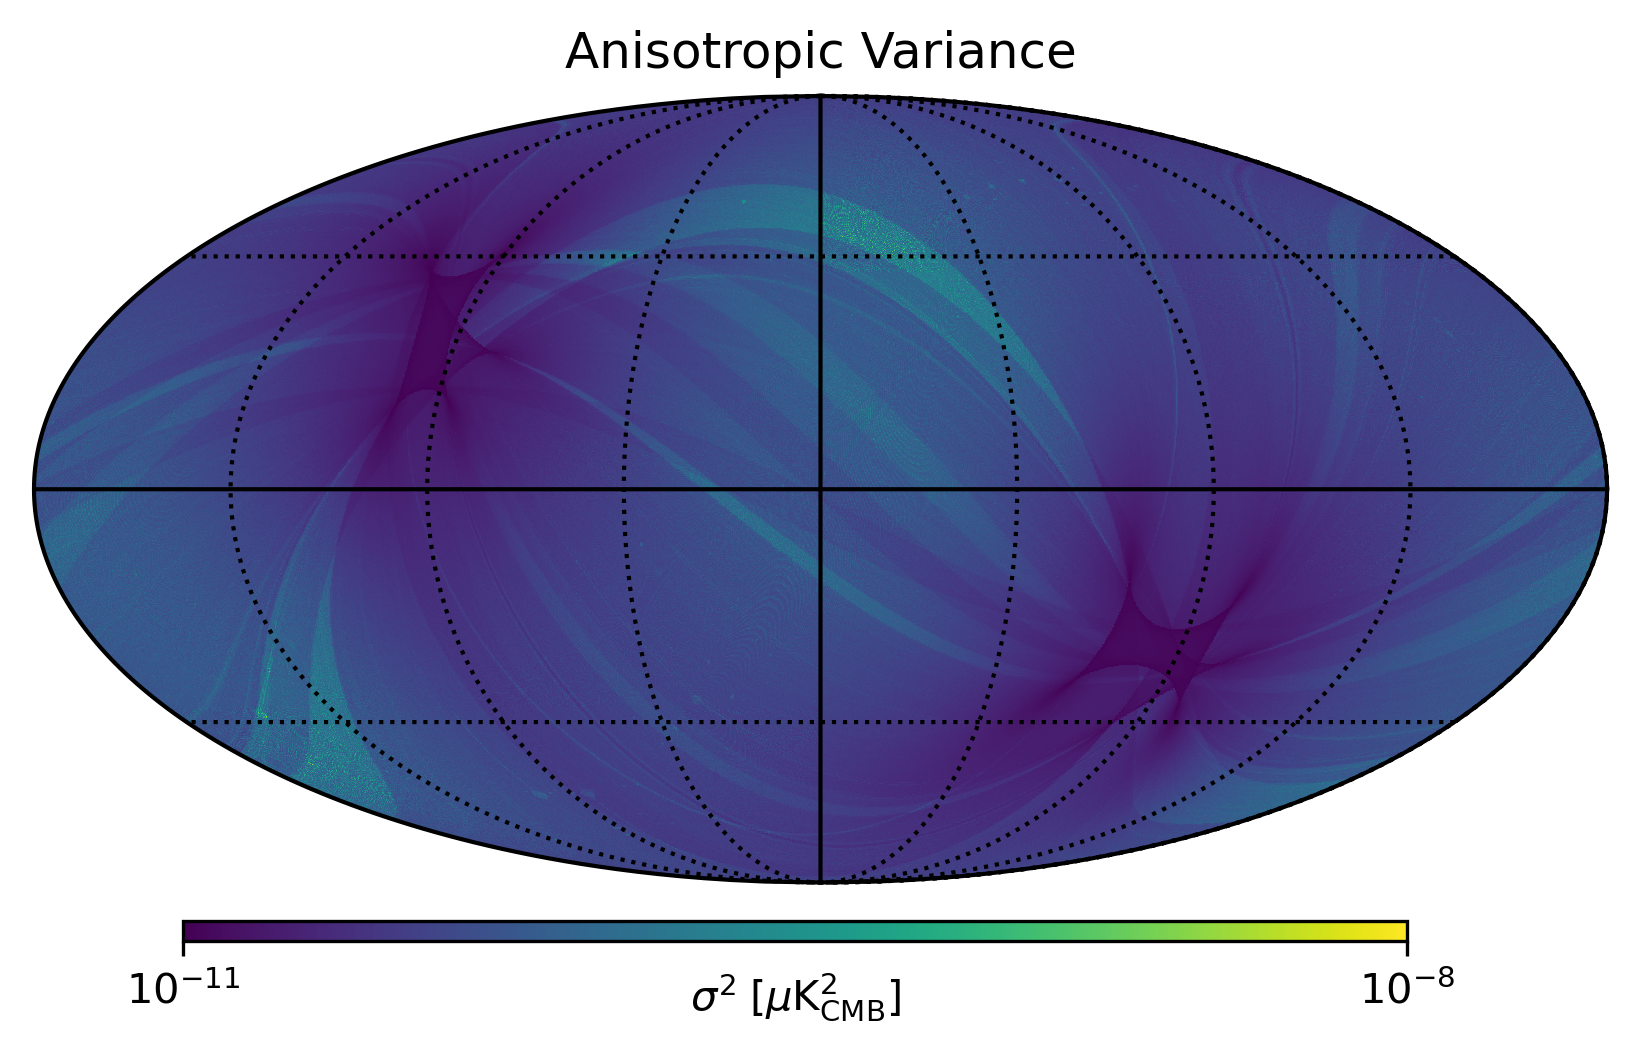

In [43]:
fp = data[100]["fp"]
m = hp.read_map(fp, field=4)

fig = plt.figure(figsize=(6.8,4.5), dpi=300)

cmap = 'viridis'

# Use a simple normalizer
# norm = cm.colors.LogNorm(vmin=1e-11, vmax=1e-8)
norm = cm.colors.Normalize(vmin=1e-11, vmax=1e-8)
# norm = cm.colors.LinearNorm(vmin=1e-11, vmax=1e-8)

hp.mollview(norm(m), title=f"Anisotropic Variance", xsize=2400, min=0, max=1, cbar=False, cmap=cmap, unit=map_unit, hold=True)  #, min=-300, max=300, xsize=2000, cmap=colombi1_cmap)
hp.graticule(dpar=45, dmer=45)

cax = fig.add_axes([0.2, 0.16, 0.6, 0.015])
mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
cb = plt.colorbar(mappable, cax=cax, orientation="horizontal")
cb.locator = MaxNLocator(nbins=2)
cb.update_ticks()
cb.set_ticks([1e-11, 1e-8])
cb.set_ticklabels(["$10^{-11}$", "$10^{-8}$"])
cb.set_label('$\\sigma^2 \\; [\\mu \\text{K}_\\text{CMB}^2]$', labelpad=-10)
plt.savefig("anisotropic_variance.pdf", format="pdf", bbox_inches="tight")